# Task 2.5 — Exploratory Data Analysis
**Paper 1:** Calibration, Uncertainty Communication, and Deployment Readiness in CKD Risk Prediction

Produces all `figures/eda_*.png` files and the demographic summary table.  
MIMIC-IV sections are placeholders that activate automatically once `data/external/mimic_ckd_cohort.csv` exists.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# ── paths ──────────────────────────────────────────────────────────────────
ROOT    = Path("../..").resolve()
FIG_DIR = ROOT / "figures"
TBL_DIR = ROOT / "tables"
FIG_DIR.mkdir(exist_ok=True)
TBL_DIR.mkdir(exist_ok=True)

UCI_PATH   = ROOT / "data" / "processed" / "uci_ckd_clean.csv"
MIMIC_PATH = ROOT / "data" / "external"  / "mimic_ckd_cohort.csv"

# ── style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
})
PALETTE = {"CKD (1)": "#d62728", "Not CKD (0)": "#1f77b4"}

# ── load UCI ───────────────────────────────────────────────────────────────
uci = pd.read_csv(UCI_PATH)
print(f"UCI loaded: {uci.shape[0]} rows × {uci.shape[1]} cols")

MIMIC_AVAILABLE = MIMIC_PATH.exists()
if MIMIC_AVAILABLE:
    mimic = pd.read_csv(MIMIC_PATH)
    print(f"MIMIC loaded: {mimic.shape[0]} rows × {mimic.shape[1]} cols")
else:
    print("MIMIC not yet available — MIMIC sections will be skipped.")

UCI loaded: 400 rows × 25 cols
MIMIC not yet available — MIMIC sections will be skipped.


## 1 — Class Distribution

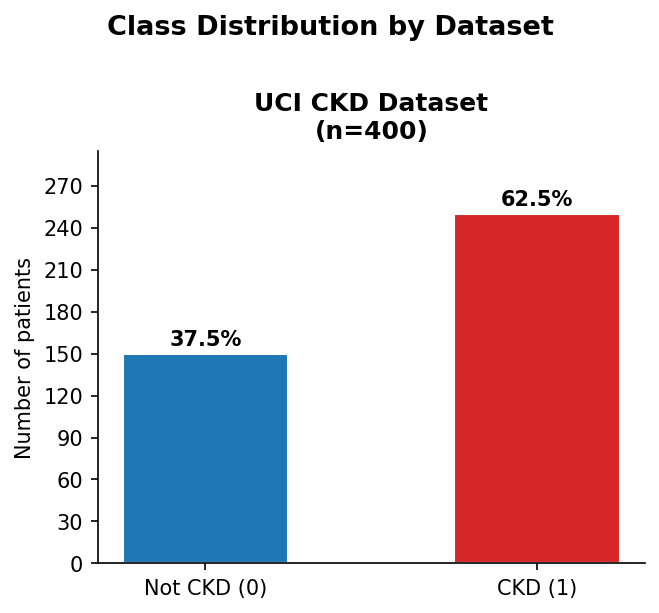

Saved → eda_class_distribution.png


In [2]:
def class_counts(df, label="class"):
    vc = df[label].value_counts().sort_index()
    return pd.DataFrame({
        "label": ["Not CKD (0)", "CKD (1)"],
        "n":     [vc.get(0, 0), vc.get(1, 0)],
        "pct":   [vc.get(0, 0)/len(df)*100, vc.get(1, 0)/len(df)*100],
    })

uci_cls = class_counts(uci)

n_panels = 2 if MIMIC_AVAILABLE else 1
fig, axes = plt.subplots(1, n_panels, figsize=(4.5 * n_panels, 4), sharey=False)
if n_panels == 1:
    axes = [axes]

for ax, (df_cls, title) in zip(axes, [(uci_cls, "UCI CKD Dataset\n(n=400)")] +
        ([(class_counts(mimic), f"MIMIC-IV Cohort\n(n={len(mimic)})")] if MIMIC_AVAILABLE else [])):
    bars = ax.bar(df_cls["label"], df_cls["n"],
                  color=[PALETTE[l] for l in df_cls["label"]], width=0.5, edgecolor="white")
    for bar, pct in zip(bars, df_cls["pct"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                f"{pct:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("Number of patients", fontsize=10)
    ax.set_ylim(0, df_cls["n"].max() * 1.18)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

fig.suptitle("Class Distribution by Dataset", fontsize=13, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "eda_class_distribution.png", bbox_inches="tight")
plt.show()
print("Saved → eda_class_distribution.png")

## 2 — Feature Correlation Heatmap

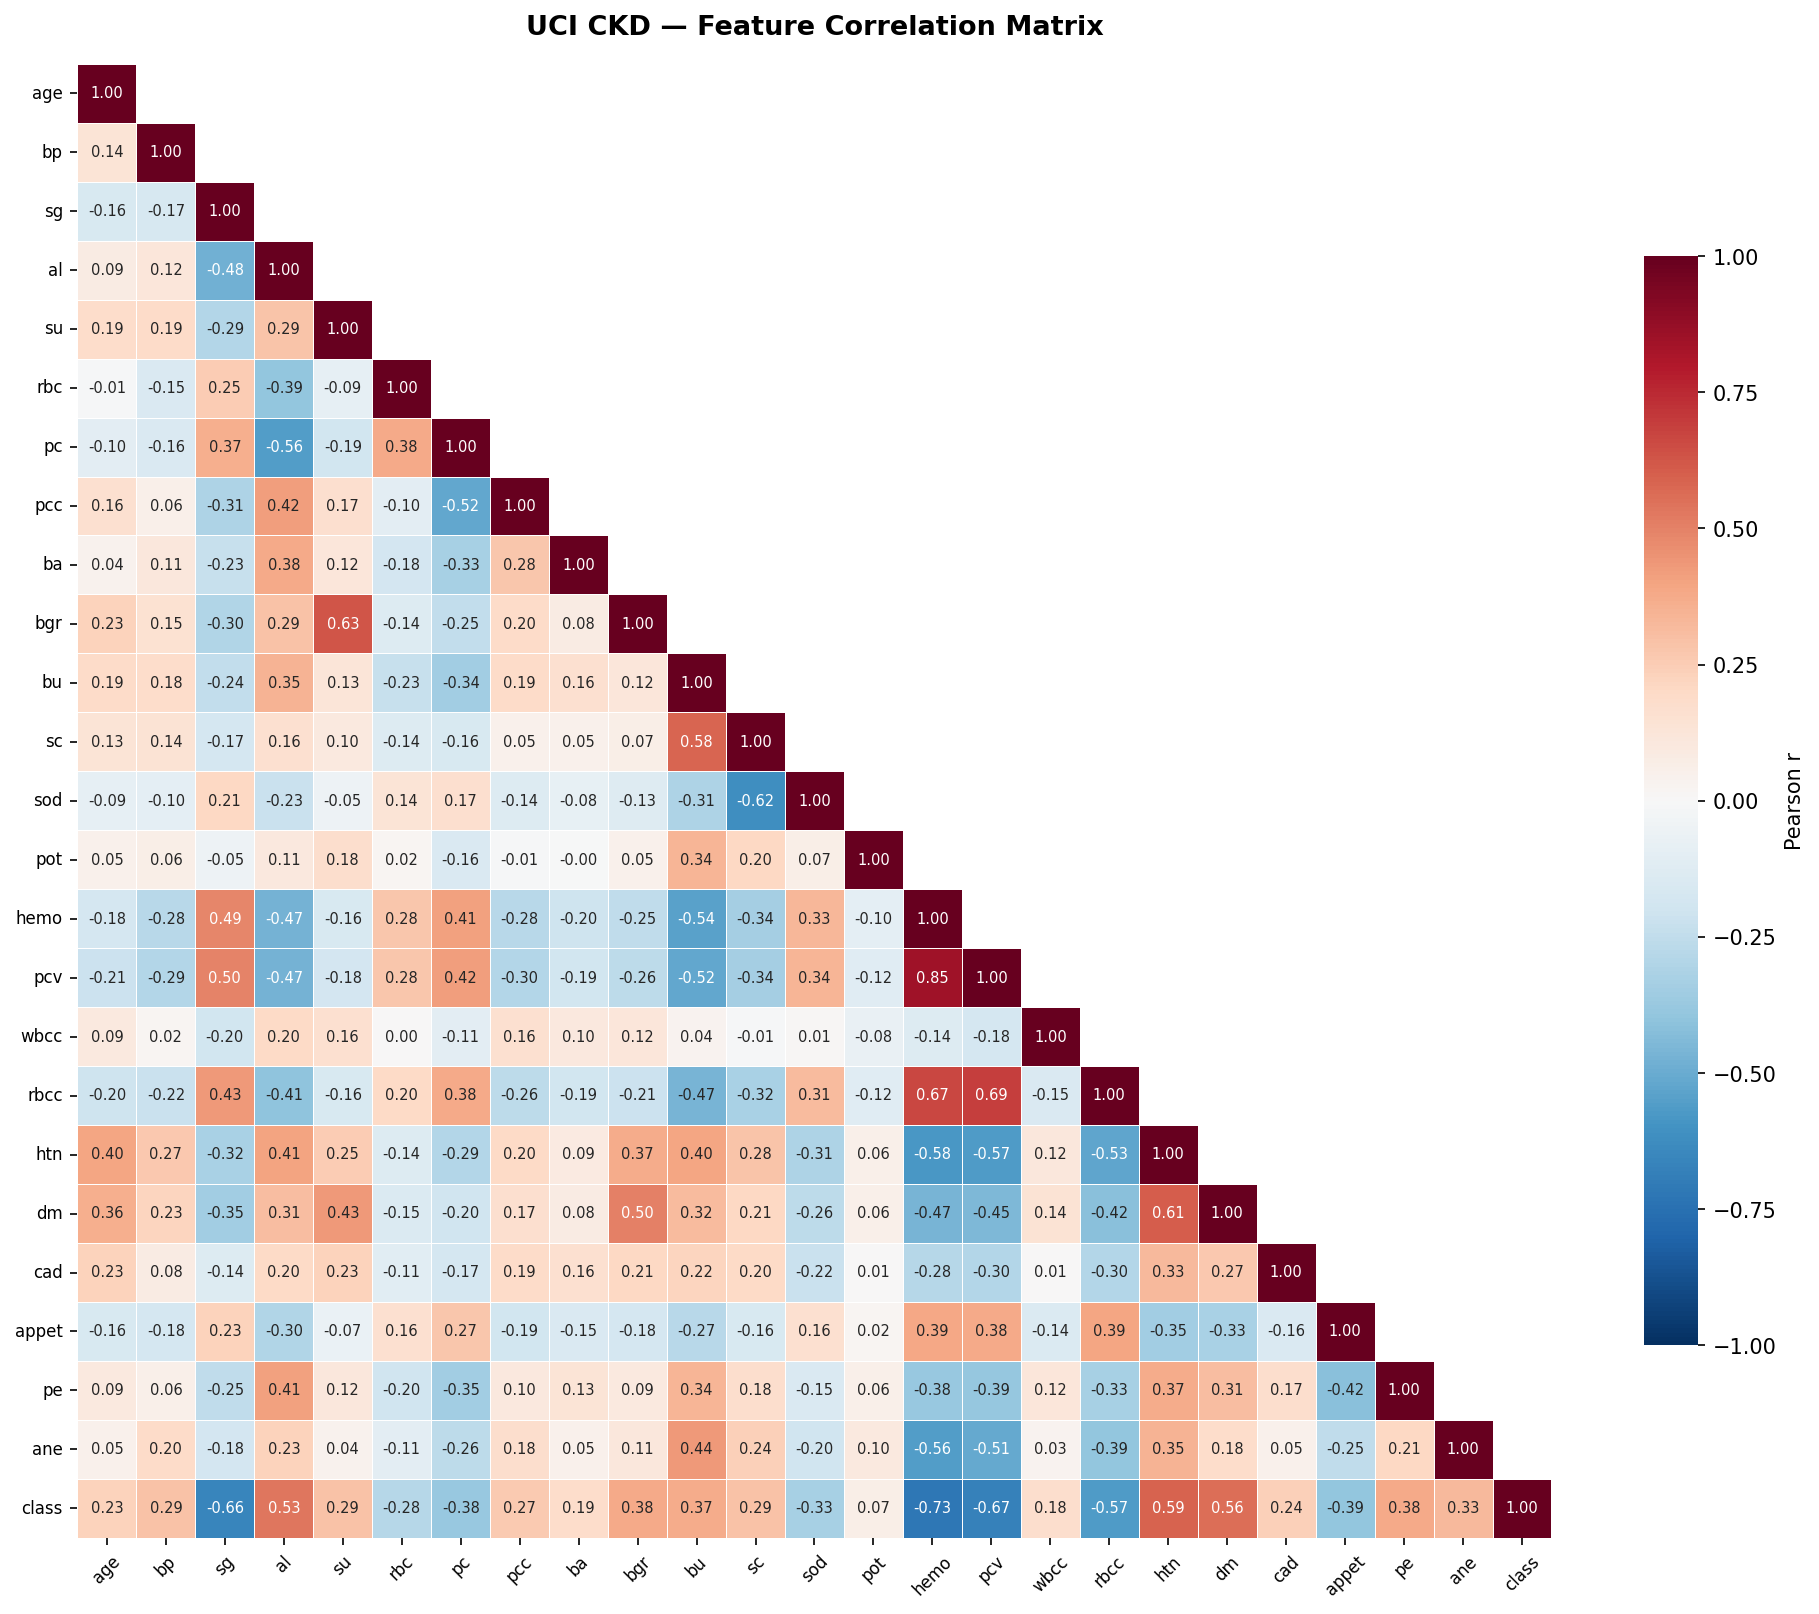

Saved → eda_correlation_heatmap.png


In [3]:
corr = uci.corr(numeric_only=True)

# reorder: put class last
cols_ordered = [c for c in corr.columns if c != "class"] + ["class"]
corr = corr.loc[cols_ordered, cols_ordered]

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)   # hide upper triangle

sns.heatmap(
    corr, mask=mask, ax=ax,
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    annot=True, fmt=".2f", annot_kws={"size": 7},
    linewidths=0.4, linecolor="white",
    cbar_kws={"shrink": 0.7, "label": "Pearson r"},
    square=True,
)
ax.set_title("UCI CKD — Feature Correlation Matrix", fontsize=13, fontweight="bold", pad=14)
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0,  labelsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "eda_correlation_heatmap.png", bbox_inches="tight")
plt.show()
print("Saved → eda_correlation_heatmap.png")

## 3 — Preliminary RF Feature Importance + Top-10 Box Plots

Top-10 features by RF importance:
   1. hemo      0.1911
   2. pcv       0.1545
   3. sc        0.1442
   4. sg        0.1161
   5. rbcc      0.0838
   6. al        0.0627
   7. htn       0.0552
   8. dm        0.0390
   9. bu        0.0307
  10. sod       0.0301


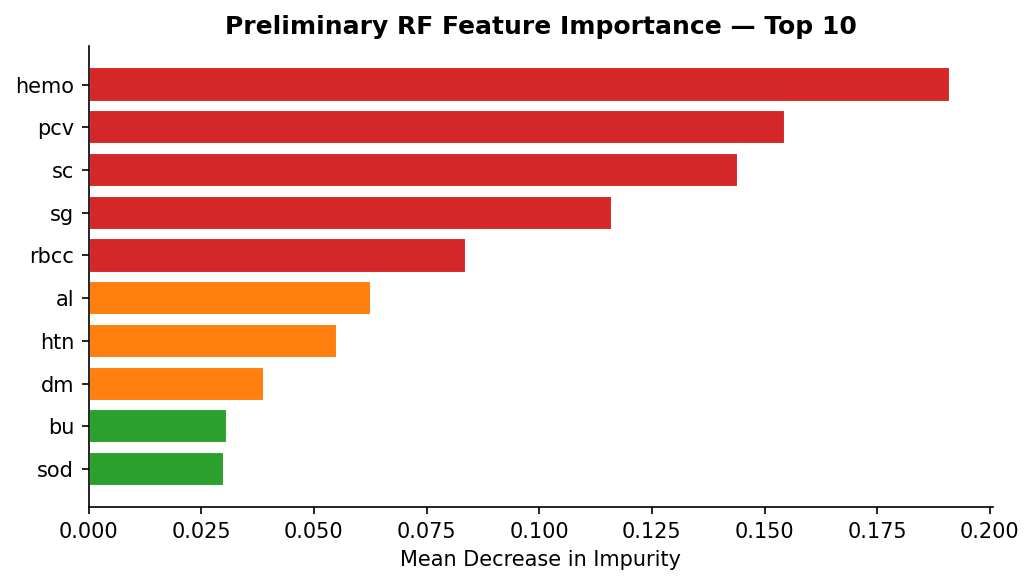

Saved → eda_feature_importance.png


In [4]:
X = uci.drop(columns="class")
y = uci["class"]

rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X, y)

importance = (pd.Series(rf.feature_importances_, index=X.columns)
               .sort_values(ascending=False))
top10 = importance.head(10).index.tolist()

print("Top-10 features by RF importance:")
for i, (feat, imp) in enumerate(importance.head(10).items(), 1):
    print(f"  {i:2d}. {feat:<8s}  {imp:.4f}")

# ── importance bar chart ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#d62728" if i < 5 else "#ff7f0e" if i < 8 else "#2ca02c"
          for i in range(len(top10))]
ax.barh(top10[::-1], importance[top10[::-1]], color=colors[::-1], edgecolor="white")
ax.set_xlabel("Mean Decrease in Impurity", fontsize=10)
ax.set_title("Preliminary RF Feature Importance — Top 10", fontsize=12, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
fig.tight_layout()
fig.savefig(FIG_DIR / "eda_feature_importance.png", bbox_inches="tight")
plt.show()
print("Saved → eda_feature_importance.png")

C:\Users\wisdo\AppData\Local\Temp\ipykernel_31908\3138494016.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\wisdo\AppData\Local\Temp\ipykernel_31908\3138494016.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\wisdo\AppData\Local\Temp\ipykernel_31908\3138494016.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\wisdo\AppData\Local\Temp\ipykernel_31908\3138494016.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

C:\Users\wisdo\AppData\Local\Temp\ipykernel_31908\3138494016.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\wisdo\AppData\Local\Temp\ipykernel_31908\3138494016.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\wisdo\AppData\Local\Temp\ipykernel_31908\3138494016.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\wisdo\AppData\Local\Temp\ipykernel_31908\3138494016.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

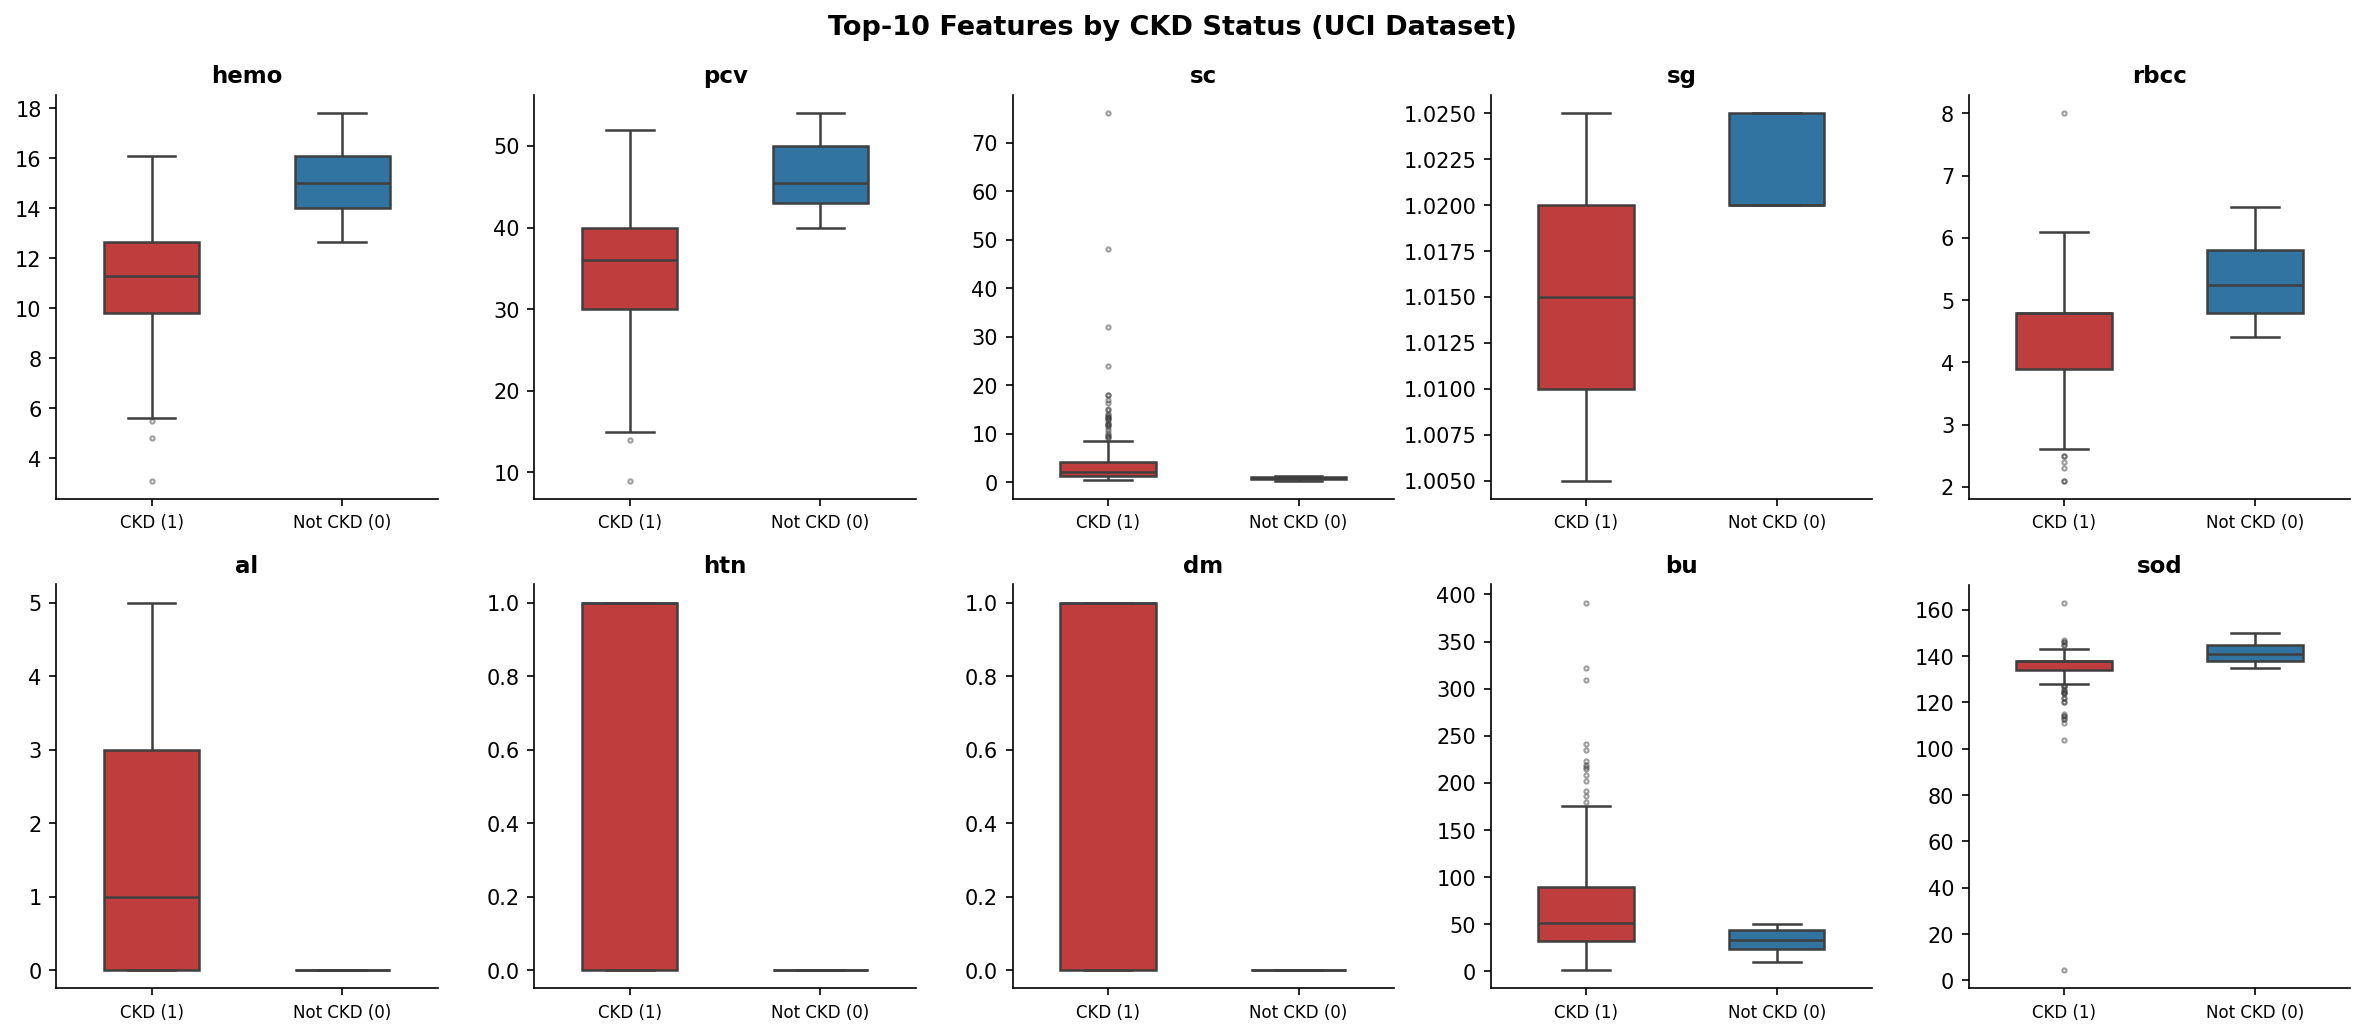

Saved → eda_boxplots_top10.png


In [5]:
# ── box plots: top-10 features by CKD class ───────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()

uci_plot = uci.copy()
uci_plot["CKD Status"] = uci_plot["class"].map({1: "CKD (1)", 0: "Not CKD (0)"})

for ax, feat in zip(axes, top10):
    sns.boxplot(
        data=uci_plot, x="CKD Status", y=feat, ax=ax,
        palette=PALETTE, width=0.5, linewidth=1.2,
        flierprops={"marker": "o", "markersize": 2, "alpha": 0.5},
    )
    ax.set_title(feat, fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", labelsize=8)

fig.suptitle("Top-10 Features by CKD Status (UCI Dataset)", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "eda_boxplots_top10.png", bbox_inches="tight")
plt.show()
print("Saved → eda_boxplots_top10.png")

## 4 — Demographic Summary Table

In [6]:
CONTINUOUS_FEATS = ["age", "bp", "sg", "bgr", "bu", "sc", "sod", "pot",
                    "hemo", "pcv", "wbcc", "rbcc"]
BINARY_FEATS     = ["htn", "dm", "cad", "pe", "ane"]

def demographic_table(df, label_col="class", dataset_name="UCI"):
    rows = []
    ckd     = df[df[label_col] == 1]
    not_ckd = df[df[label_col] == 0]

    rows.append({"Feature": "N", "Overall": len(df),
                 "CKD": len(ckd), "Not CKD": len(not_ckd), "Type": "count"})

    for feat in CONTINUOUS_FEATS:
        if feat not in df.columns:
            continue
        def fmt(s): return f"{s.median():.1f} ({s.quantile(0.25):.1f}–{s.quantile(0.75):.1f})"
        rows.append({"Feature": feat,
                     "Overall": fmt(df[feat]),
                     "CKD":     fmt(ckd[feat]),
                     "Not CKD": fmt(not_ckd[feat]),
                     "Type": "continuous"})

    for feat in BINARY_FEATS:
        if feat not in df.columns:
            continue
        def pct(s): return f"{s.sum()} ({s.mean()*100:.1f}%)"
        rows.append({"Feature": f"{feat} = yes",
                     "Overall": pct(df[feat]),
                     "CKD":     pct(ckd[feat]),
                     "Not CKD": pct(not_ckd[feat]),
                     "Type": "binary"})

    tbl = pd.DataFrame(rows).set_index("Feature")
    tbl.columns.name = dataset_name
    return tbl

uci_demo = demographic_table(uci, dataset_name="UCI")
uci_demo.to_csv(TBL_DIR / "t_uci_demographics.csv")
print(f"UCI demographic table ({uci_demo.shape[0]} rows) → t_uci_demographics.csv\n")
display(uci_demo.drop(columns="Type"))

if MIMIC_AVAILABLE:
    mimic_demo = demographic_table(mimic, dataset_name="MIMIC")
    mimic_demo.to_csv(TBL_DIR / "t_mimic_demographics.csv")
    print("\nMIMIC demographic table → t_mimic_demographics.csv")
    display(mimic_demo.drop(columns="Type"))

UCI demographic table (18 rows) → t_uci_demographics.csv



UCI,Overall,CKD,Not CKD
Feature,,,
N,400,250,150
age,55.0 (42.0–64.0),59.0 (48.0–65.0),46.0 (34.0–58.0)
bp,80.0 (70.0–80.0),80.0 (70.0–90.0),70.0 (60.0–80.0)
sg,1.0 (1.0–1.0),1.0 (1.0–1.0),1.0 (1.0–1.0)
bgr,121.0 (101.0–150.0),127.5 (111.2–210.0),109.0 (94.2–122.8)
bu,42.0 (27.0–61.8),51.0 (32.0–89.8),33.5 (24.2–44.0)
sc,1.3 (0.9–2.7),2.2 (1.3–4.2),0.9 (0.6–1.1)
sod,138.0 (135.0–141.0),138.0 (134.0–138.0),141.0 (138.0–145.0)
pot,4.4 (4.0–4.8),4.4 (4.1–4.6),4.5 (3.7–4.9)


## 5 — Summary of Saved Figures

In [7]:
eda_figs = sorted(FIG_DIR.glob("eda_*.png"))
print(f"EDA figures saved ({len(eda_figs)} total):")
for f in eda_figs:
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<45s}  {size_kb:6.1f} KB")

eda_tbls = [TBL_DIR / "t_uci_demographics.csv", TBL_DIR / "t_uci_missingness.csv"]
print(f"\nEDA tables saved:")
for t in eda_tbls:
    if t.exists():
        print(f"  {t.name}")

print("\n✓ Task 2.5 complete — notebook ran end-to-end without errors.")

EDA figures saved (4 total):
  eda_boxplots_top10.png                          232.0 KB
  eda_class_distribution.png                       75.4 KB
  eda_correlation_heatmap.png                     635.1 KB
  eda_feature_importance.png                       60.2 KB

EDA tables saved:
  t_uci_demographics.csv
  t_uci_missingness.csv

✓ Task 2.5 complete — notebook ran end-to-end without errors.
